# it is an classification algoritham

basic idea of naive bayes is

The main idea behind the Naive Bayes classifier is to use Bayes' Theorem to classify data based on the probabilities of different classes given the features of the data. It is used mostly in high-dimensional text classification

let's say our dataset has three features and output has two classes

now whenver we get a value of prediction we will calculate
lets' say we get this time data for prediction where feature 1= A feature 2 =B feature 3=C

now we will calculate P(class 0/(A,B,C)) and P(class1/(A,B,C)) and whoever probability is more we will return that class as output

here P(A,B,C) means that P(A and B and C) = P(A intersection B intersection C)

P(class k / (A,B,C)) = ( P( (A,B,C) / class k ) * P (class k) )/ P((A,B,C))

now P((A,B,C)) will be common in denominator for every classs so we dont need to calculate it and 

it is proved that P((A,B,C) / class k) = P(A/class k)*P(B/class k)*P(C/class k)

for example

<img src="../images/NB (1).png">
<img src="../images/NB (2).png">
<img src="../images/NB (3).png">
<img src="../images/NB (4).png">
<img src="../images/NB (5).png">
<img src="../images/NB (6).png">

# mathematics 

<img src="../images/nb (1).jpg">
<img src="../images/nb (2).jpg">

# custom class

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../Datasets/play_tennis.csv")
df.drop('day',axis=1,inplace=True)
df.head()

,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.2,random_state=42)

In [30]:
class naiveBayes:
    def __init__(self):
        self.class_probs={}
        self.feature_probs={}

    def train(self,X,y):
        for i in np.unique(y):
            self.class_probs[i]=(y==i).sum()/len(y)
            self.feature_probs[i]=dict()
            
        for clss in self.feature_probs.keys():
            ct=X.loc[y==clss,:]
            print(ct)
            for i in range(ct.shape[1]):
                self.feature_probs[clss][i]=dict()
                for feature in np.unique(ct.iloc[:,i]):
                    self.feature_probs[clss][i][feature]=(ct.iloc[:,i]==feature).sum()/len(ct)
        self.possC=np.unique(y)
        
    def test_one(self,X):
        max_prbb,ind=0,0
        for clss in self.possC:
            c_prbb=1
            for i in range(len(X)):
                c_prbb*=self.feature_probs[clss][i][X[i]]
            if c_prbb>max_prbb:
                max_prbb=c_prbb
                ind=clss
            
        return ind

    def test(self,X):
        return [self.test_one(i) for i in X]

In [5]:
nb=naiveBayes()
nb.train(X_train,y_train)
nb.test_one(['Sunny','Hot','High','Weak'])

   outlook  temp humidity    wind
5     Rain  Cool   Normal  Strong
1    Sunny   Hot     High  Strong
13    Rain  Mild     High  Strong
7    Sunny  Mild     High    Weak
     outlook  temp humidity    wind
12  Overcast   Hot   Normal    Weak
8      Sunny  Cool   Normal    Weak
2   Overcast   Hot     High    Weak
4       Rain  Cool   Normal    Weak
10     Sunny  Mild   Normal  Strong
3       Rain  Mild     High    Weak
6   Overcast  Cool   Normal  Strong


'No'

# The problem

till now the things we have done it requires our features must also be categorical 

# The solution

we can use the distribution which fits best to our numerical continious variable for calculating probab 



In [9]:
df= pd.read_csv('../Datasets/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [28]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
def drawDist(cols):
    for i in cols:
        std=StandardScaler()
        x=std.fit_transform(df[[i]])
        sns.distplot(x,hist=False,label=i)
        plt.title(f"Distribution plot of {i}")
        normal_dist=np.random.normal(loc=0,scale=x.std(),size=1000)
        sns.distplot(normal_dist,hist=False,label='Normal distribution')
        plt.legend()
        plt.show()

C:\Users\panka\AppData\Local\Temp\ipykernel_15524\2220662758.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x,hist=False,label=i)
C:\Users\panka\AppData\Local\Temp\ipykernel_15524\2220662758.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_dist,hist=False,label=

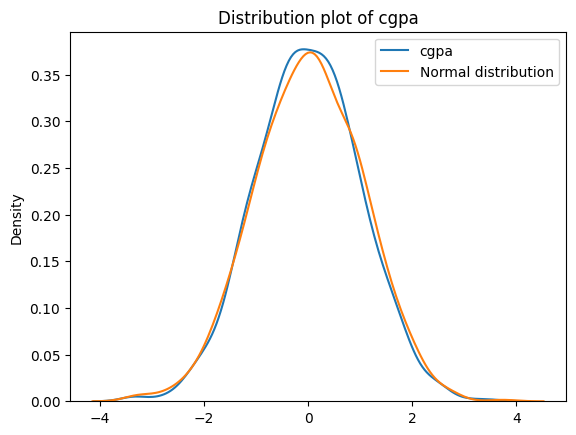

C:\Users\panka\AppData\Local\Temp\ipykernel_15524\2220662758.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x,hist=False,label=i)
C:\Users\panka\AppData\Local\Temp\ipykernel_15524\2220662758.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_dist,hist=False,label=

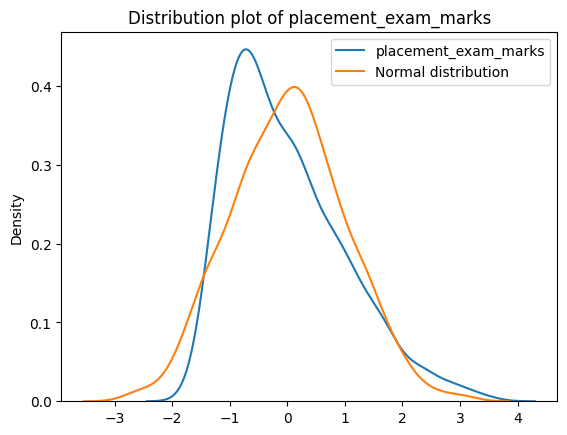

In [29]:
drawDist(df.columns.to_list()[:-1])

In [ ]:
# sckit learn gives only option to use one type of distribution for every col